# Aufgabe 3
In Aufgabe 3 sollten wir eine Weatstone Brücke aufbauen und die Brüceknspannung messen. Dabei sollen wir die Brückenspannung $U_B$ als Funktiuon von $R_4$ darstellen, wobei $R_4$ ein Dekadenwiederstand war, und den Wiederstand $R_2$ bestimmen. Weiteres galt in der Schaltung $R_1 = R_3$. DIe volle Schaltung ist nach dem Experimentplan in [Abbildung @fig-experimentieraufbau3] zu sehen.
Für den Versuch wurde insgesamt 84 Messungen aufgenommen, wobei der Dekadenwiederstand von 0 $\Omega$ bis 10 $k\Omega$ variiert wurde. Die Messung der Brückenspannung $U_B$ wurde mit einem Multimeter ($\pm 0.5$%$+3$Digits siehe [Fehlertabelle](#fig-fehlertabelle) Multimeter) durchgeführt.
![Experimentieraufbau einer Weatstonschen Brücke für Aufgbae 3](./Bilder/Weartstonebrücke.png){#fig-experimentieraufbau3 width="50%"}

## Theoretische  Grundlagen
Bei der Weatstone Brücke handelt es sich um eine Schaltung, die aus vier Widerständen besteht, die in Form eines Rechtecks angeordnet sind. Im Gleichgewichtszustand gilt $U_B = 0V$:
$$ \frac{R_2}{R_1} = \frac{R_4}{R_3} $${#eq-gleichgewicht}
Für unsere Weatstonebrücke gilt insbesondere da $R_1 = R_3$, dass im Gleichgewichtzustand $R_2 = R_4$ was sich aus der obigen [Gleichung](#eq-gleichgewicht) ergibt.
Zudem gilt allegmein für Weatstonebrücken immer, das die Brückenspannung $U_B$ wie folgt von den Widerständen abhängt:
$$ U_B = U_2 - U_4 = U_3 - U_1 $${#eq-ub-formel}
Fudem gilt für die Schaltung auch das ohmsche Gesetz.
$$U = R I$${#eq-ohmschesgesetz}

## Theorie und Messwerte
Mit den Formeln die in [Theoretische Grundlagen](#theoretische--grundlagen) gezeigt wurden. Kann nun die Formel zur Berechnung des theoretischen Wertes gezeigt werden. Dabei wird die Brückenspannung $U_B$ als Funktion von $R_4$ dargestellt.
Dafür können wir das [Ohmsche Gesetz]{#eq-ohmschesgesetz} und die allgemeine Formel für $U_B$ nutzen. So kommt man auf eine neue Formel:
$$U_B = R_2 I_2 -R_4I_4$${#eq-ub-vereinfachung}
Da $R_1 = R_3$ gilt, können wir aus dem [ohmschen Gesetz]{#eq-ohmschesgesetz} $I_2$ und $I_4$ wie folgt vereinfacht darstellen:
$$I_2 = \frac{U}{R_2 + R_4}$${#eq-ub-vereinfachung1}
$$I_4 = \frac{U}{R_1 + R_4}$${#eq-ub-vereinfachung2}
Damit kann die Formel für die Brückenspannung $U_B$ weiter vereinfacht werden:
$$U_B = R_2 \frac{U}{R_2 + R_4} - R_4 \frac{U}{R_1 + R_4}$${#eq-ub-vereinfachung3}
Damit lautet die geschlossene Formel für die theoretische Brückenspannung:
$$U_B(R_4) = U \left( \frac{R_2}{R_2 + R_4} - \frac{R_4}{R_1 + R_4} \right)$${#eq-formel-hergeleitet}
FÜr den theoretischen Wert wurden die Wiederstandswerte für $R_4$ von 0 $\Omega$ bis 10000 $\Omega$ genommen in 10 Schritten genommen. Für die Spannung wird der Werte $5V$ genommen

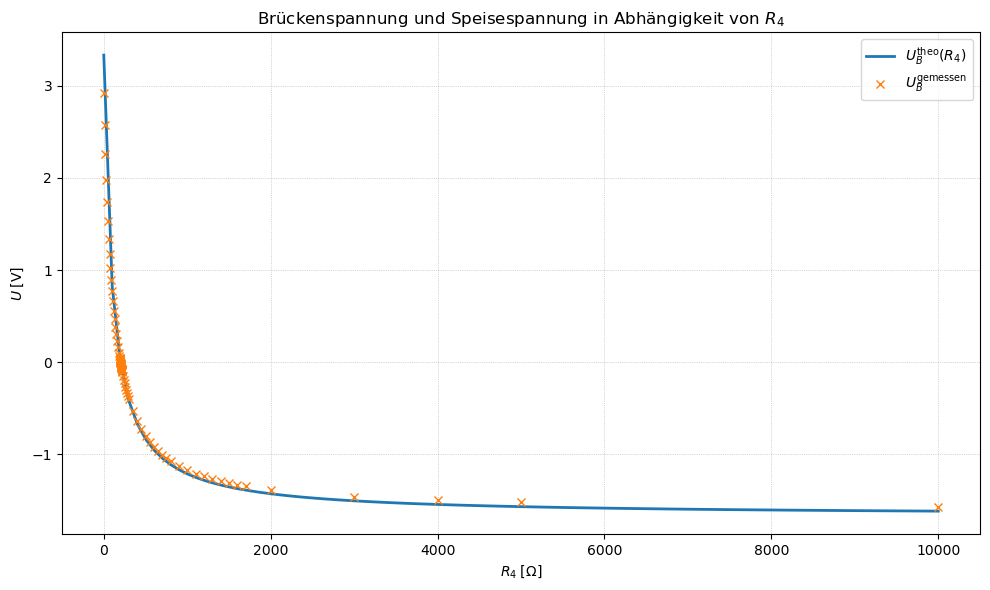

In [ ]:
#| label: fig-reihe-123
#| fig-cap: Brückenspannung und Speisespannung in Abhängigkeit von $R_4$
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Parameter ===
U = 5.0               # Speisespannung [V]
R1 = R3 = 100
R2 = 200            # Widerstandswerte [Ω]

# Theoretische Kurve berechnen
R_4 = np.linspace(0, 10000, 100)  # Widerstandswerte von 0 bis 10kΩ in 100 Schritten
U_B_theo = U * (R2/(R1 + R2) - R_4/(R1 + R_4))

# CSV-Datei mit den Messwerten laden
df = pd.read_csv('Daten/Daten_Aufgabe_3.csv')
df.columns = ['R_4 [Ω]', 'U_B gemessen [V]', 'U gemessen [V]']

# Plot erstellenohm
plt.figure(figsize=(10, 6))

# Theoretische Kurve
plt.plot(R_4, U_B_theo,
         label=r'$U_B^\mathrm{theo}(R_4)$',
         linestyle='-',
         linewidth=2)

# Messkurven
plt.plot(df['R_4 [Ω]'], df['U_B gemessen [V]'],
         marker='x', linestyle='',
         label=r'$U_B^\mathrm{gemessen}$')

#plt.yticks(np.arange(0, 60, 10))  # Y-Achse von -5V bis 5V in Schritten von 1V
#plt.xscale('log')  # Log-Skala (Dann bricht es irgendwie, warum auch immer)
plt.xlabel(r'$R_4\;[\Omega]$')
plt.ylabel(r'$U\;[\mathrm{V}]$')
plt.title('Brückenspannung und Speisespannung in Abhängigkeit von $R_4$')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Auswertung mit nichlinearem Fit

Bei der Auswertung der Messwerte wurde ein nichtlinearer Fit durchgeführt. Dabei wurde die [Formel](#eq-formel-hergeleitet) für die Brückenspannung $U_B(R_4)$ als Funktion von $R_4$ verwendet. Dabei kam man auf einen geschätzten Widerstand für R2 von197.12 $\Omega$ mit einer Standardabweichung von 1.48 $\Omega$ was dem im Experiment genommenen Wert von 200 $\Omega$ sehr nahe kommt wie in [Abbildung @fig-nonlinear-fit].

Geschätzter Widerstand R2: 197.12 Ω
Standardabweichung des geschätzten Widerstands R2: 1.48 Ω


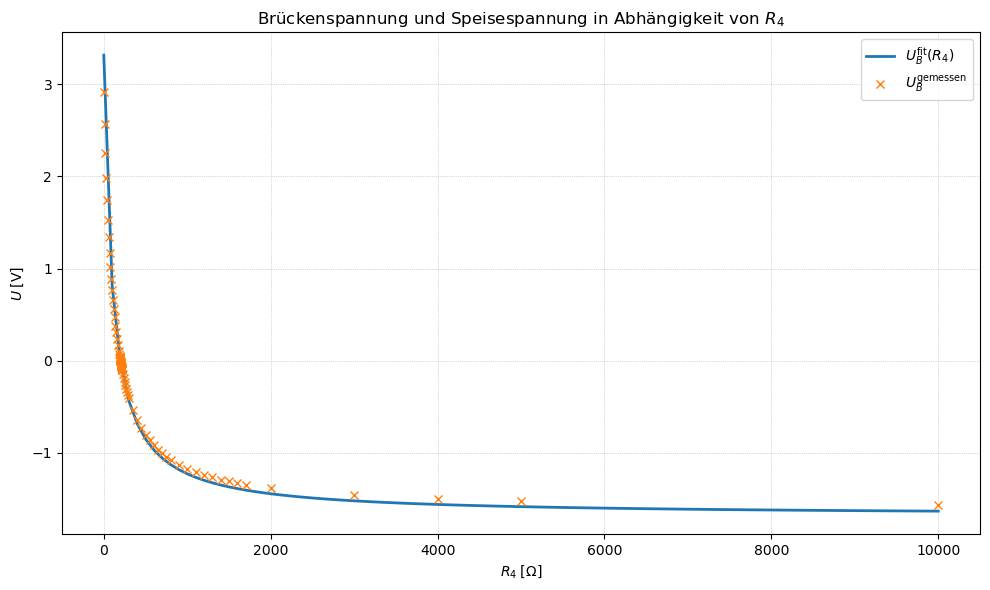

In [ ]:
#| label: fig-nonlinear-fit
#| fig-cap: R über U mit linearem Fit für Reihneschaltung
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# === Parameter ===
U = 5.0               # Speisespannung [V]
R1 = R3 = 100
R_2 = 200            # Widerstandswerte [Ω]

# Theoretische Kurve berechnen
R_4 = np.linspace(0, 10000, 100)  # Widerstandswerte von 0 bis 10kΩ in 100 Schritten
U_B_theo = U * (R_2/(R1 + R_2) - R_4/(R1 + R_4))

def bruecke(R4, R2):
    return U * (R2 / (R1 + R2) - R4 / (R1 + R4))

# CSV-Datei mit den Messwerten laden
df = pd.read_csv('Daten/Daten_Aufgabe_3.csv')
df.columns = ['R_4 [Ω]', 'U_B gemessen [V]', 'U gemessen [V]']

# Curve-Fit
params, covariance = curve_fit(bruecke, df['R_4 [Ω]'], df['U_B gemessen [V]'], p0=[R_2])
# Extrahiere den geschätzten Widerstand R2
R2_estimated = params[0]
#print(f"Geschätzter Widerstand R2: {R2_estimated:.2f} Ω")
sigma_R2 = np.sqrt(np.diag(covariance))[0]
#print(f"Standardabweichung des geschätzten Widerstands R2: {sigma_R2:.2f} Ω")

# Plot erstellen
plt.figure(figsize=(10, 6))

# Theoretische Kurve
plt.plot(R_4, bruecke(R_4, R2_estimated),
         label=r'$U_B^\mathrm{fit}(R_4)$',
         linestyle='-',
         linewidth=2)

# Messkurven
plt.plot(df['R_4 [Ω]'], df['U_B gemessen [V]'],
         marker='x', linestyle='',
         label=r'$U_B^\mathrm{gemessen}$')

#plt.yticks(np.arange(0, 60, 10))  # Y-Achse von -5V bis 5V in Schritten von 1V
#plt.xscale('log')  # Log-Skala (Dann bricht es irgendwie, warum auch immer)
plt.xlabel(r'$R_4\;[\Omega]$')
plt.ylabel(r'$U\;[\mathrm{V}]$')
plt.title('Brückenspannung und Speisespannung in Abhängigkeit von $R_4$')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Feherbetrachtung
Für die Fehlerbtrachtung benutzen wir die [Fehlertabelle]{#fig-fehlertabelle} für das Digitalmultimeter.
Für die theoretischen Werte wurde immer 5V genommen. Die reale Spannungsquelle, fluktuiert aber immer mit dem Strom, so war die echte Spannung immer im bereich 4,99V bis 4,97V. Was eine leichte abweichung der theorie und den Mwssdaten erklähren können.
Zudemm kann man für alle Experimente sagen, dass immer eine ideale Stromkreis angenommen wurde, das heißt es wurde die Wiederstand der Kabel, des Breadboards und des Multimeters wurden nicht beachtet.